### Exercise 1: Exploring and Visualizing MNIST Data

1. Import `matplotlib.pyplot as plt` and load the MNIST dataset directly from `tensorflow.keras.datasets.mnist`.

2. Unpack the loaded data into your four standard variables: `X_train, y_train, X_test, and y_test`.

3. Print the `.shape` attribute of `X_train` and `X_test` to explicitly observe the number of images in each set and their `28 x 28` pixel dimensions.

4. Print the `.shape` attribute of `y_train` and `y_test` to confirm they are 1D arrays containing the correct number of corresponding labels.

5. Print the raw data of the very first image (`X_train[0]`) to your console so you can observe the actual matrix of pixel values ranging from 0 to 255.

6. Define a Python function called `plot_digit` that accepts three arguments: the `image data array`, the `label array`, and an `index number`.

7. Inside this function, use `plt.imshow()` with the argument `cmap='gray'` to render the specific 28x28 matrix as a visual image.

8. Add a line inside your function to set the plot title (`plt.title()`) so it clearly displays the true label (the actual number) associated with that image.

9. Call your new `plot_digit` function three different times using different index numbers (e.g., 0, 15, and 99) to verify it works and to explore the dataset.

10. Bonus Challenge: Upgrade your function to accept a list of indices and use `plt.subplots()` to effectively display a grid of multiple digits side-by-side

In [1]:
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
import numpy as np

# 1. Load and unpack the dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [4]:
X_train.shape
X_test.shape

(10000, 28, 28)

In [7]:
np.set_printoptions(linewidth=150)

print(X_train[0])


[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247 241   0   

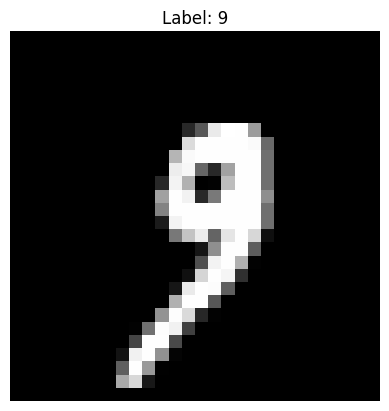

In [24]:
def plot_digit(image_data = X_train, label_data = y_train, index=0):

    plt.imshow(image_data[index], cmap='gray')
    plt.title(f"Label: {label_data[index]}")
    plt.axis('off')
    plt.show()

# plot_digit()

plot_digit(image_data= X_test, label_data= y_test, index=1000)

In [ ]:
for i, idx in enumerate(image_indicies):
    print(idx)

10
20
30
40
50


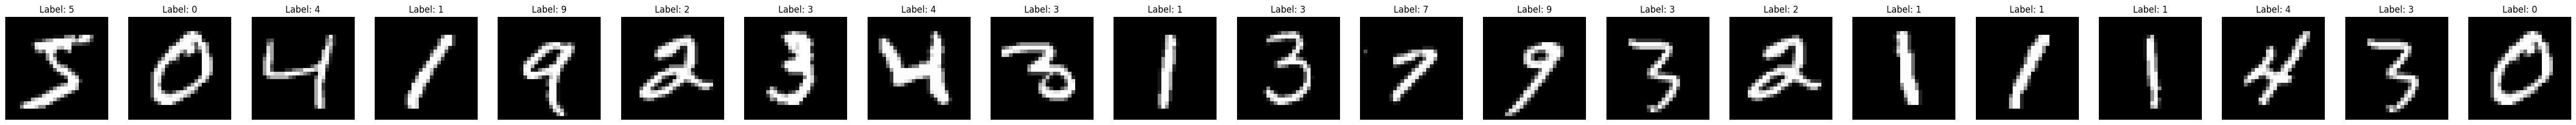

In [34]:
# won't create a function, but i will demo subplots

# will take a list of digits to be printed
def plot_digits(image_data = X_train, label_data = y_train, image_indicies= [10, 20, 30, 40, 50]):

    fig, axes = plt.subplots(1, len(image_indicies), figsize = ( len(image_indicies)*3 , 3)) # 1, 5, (width, height)

    for i, idx in enumerate(image_indicies):
        axes[i].imshow(image_data[idx], cmap='gray')
        axes[i].set_title(f"Label: {label_data[idx]}")
        axes[i].axis('off')
    
    plt.show()
    
    # create an empty list
    # append each label in the for loop
    # return a list of labels for each of these digits


plot_digits(image_indicies= [0,1,2,3,4,5,10,20,30,40,50,29,33,44,5,6,77,8,9,44,1])

### Exercise 2: Preprocessing the Image Data
1. Find the `minimum` and `maximum` `pixel values` in your `X_train` array using the `.min()` and `.max()` methods to see the current scale of your data.

2. `Scale` `your` `training` `data` by dividing the entire `X_train` array by `255.0`, and save this into a new variable called `X_train_scaled`.

3. Perform the exact same operation on your `test data`, dividing `X_test` by `255.0` and saving it as `X_test_scaled`.

4. Verify your transformation by `printing the` `.min() and .max()` of your new X_train_scaled array to confirm all pixel values are now squeezed between 0.0 and 1.0.

5. Print the `.shape` of `X_train_scaled` to confirm that the mathematical operation did not break the structure of your `60,000` images or their 28x28 dimensions.

6. Print the `first five labels` from your `y_train` array just to observe that the targets are standard integers (like 5, 0, 4, 1, 9), which tells us exactly which loss function to use in the next step.

7. Create the subplots for 5 images in the `X_train_scaled` to check if images look the same after being scaled

In [31]:
print(X_train.min()," to ", X_train.max())

0  to  255


In [ ]:
X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

Later we have to feed this data to Neural Networks. NNs like data that is small in proportions. Calcuating gradients is easier on smaller number

In [36]:
print(X_train_scaled.min()," to ", X_test_scaled.max())

0.0  to  1.0


In [42]:
y_train[:5]

# np.set_printoptions(linewidth=150)

# print(X_train_scaled[0].round(2))

array([5, 0, 4, 1, 9], dtype=uint8)

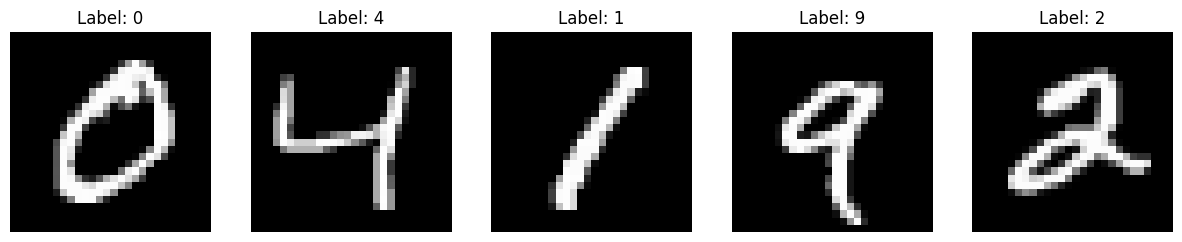

In [38]:
plot_digits(image_data= X_train_scaled, image_indicies= [1,2,3,4,5])

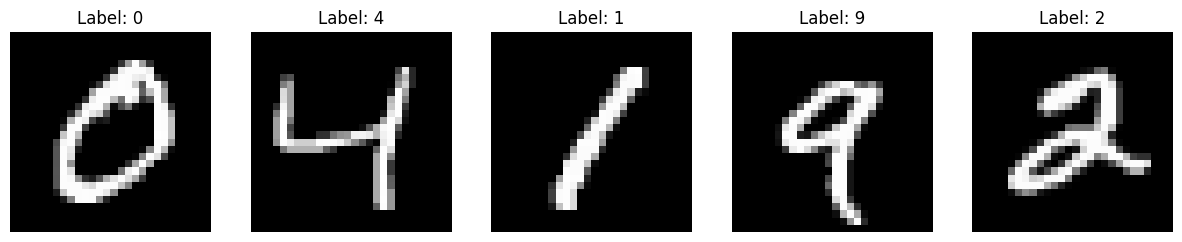

In [39]:
plot_digits(image_data= X_train, image_indicies= [1,2,3,4,5])